This notebook trains a simple linear Ridge regression model on the running dataset stored in the SQLite database.

Features used: distance (meters), age, year, sex (0/1). Target: time in seconds.

In [94]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = "/Users/darraghdonnelly/dev/Database/recovered.db"
TEST_SIZE = 0.20

# connect to db
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(
        f"SELECT src, sex, age, distance_m, time_s FROM concat_results",
        conn,
    )

print(f"rows: {len(df)}")
df.head()

rows: 143442


,src,sex,age,distance_m,time_s
0,CherryBlossom2017,1,21,16093,3217.0
1,CherryBlossom2017,1,22,16093,3232.0
2,CherryBlossom2017,1,31,16093,3276.0
3,CherryBlossom2017,1,33,16093,3285.0
4,CherryBlossom2017,1,35,16093,3288.0


In [95]:
# split dataset into three buckets by distances
df["distance_bucket"] = (
    df["distance_m"].round().astype(int)
    .map({42195: "42k", 16093: "16k", 5000: "5k"})
)

df["distance_bucket"].head

<bound method NDFrame.head of 0         16k
1         16k
2         16k
3         16k
4         16k
         ... 
143437    16k
143438    16k
143439    16k
143440    16k
143441    16k
Name: distance_bucket, Length: 143442, dtype: str>

In [96]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# split dataset into train and test - stratified by distance
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42, stratify=df["distance_bucket"])

# store features in list
features = ["distance_m", "age", "sex"]

X_train = train_df[features]

# set target to time
y_train = train_df["time_s"]

# convert distances to labeled buckets (5k, 16k, 42k) so stratified k folding can be done
train_buckets = train_df["distance_bucket"]

X_test = test_df[features]
y_test = test_df["time_s"]

model = Ridge(alpha=0.1)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# get mean abs error scores
cv_mae = -cross_val_score(
    model,
    X_train,
    y_train,
    cv = skf.split(X_train, train_buckets),     # carry out strat kfold on training data for the 3 distances
    scoring="neg_mean_absolute_error"
)

# get r sqrd scores
cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=skf.split(X_train, train_buckets),
    scoring="r2"
)
# print results
print("CV MAE:", cv_mae.mean(), "with standard deviation of ±", cv_mae.std())
print("CV R2:", cv_r2.mean(), "with standard deviation of ±", cv_r2.std())

# fit model and run on test once
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))

CV MAE: 2260.948412501333 with standard deviation of ± 8.21752714376234
CV R2: 0.7207525808791977 with standard deviation of ± 0.0010935765217340327
Test R2: 0.7191348926433618


In [102]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "alpha": [ 0.1, 0.5, 0.75, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# randomised search used instead of gridsearch due to the large hp space
search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv.split(X_train, train_buckets),
)

search.fit(X_train, y_train)

print(search.best_params_)
print(-search.best_score_)


{'alpha': 0.1}
-0.8642334721123666


In [97]:
from sklearn.metrics import mean_absolute_error

test_eval = test_df.copy()
test_eval["pred_time_s"] = y_pred
test_eval["actual_time_s"] = y_test.values

for bucket in ["5k", "16k", "42k"]:
    bucket_rows = test_eval[test_eval["distance_bucket"] == bucket]
    mae_seconds = mean_absolute_error(bucket_rows["actual_time_s"], bucket_rows["pred_time_s"])
    mae_minutes = mae_seconds / 60

    print(bucket)
    print("MAE seconds:", mae_seconds)
    print("MAE minutes:", mae_minutes)
    print()



5k
MAE seconds: 972.255166787838
MAE minutes: 16.2042527797973

16k
MAE seconds: 913.7435036420235
MAE minutes: 15.229058394033725

42k
MAE seconds: 2736.450392398435
MAE minutes: 45.60750653997391



In [98]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# set features and targets
features = ["distance_m", "age", "sex"]
X = df[features]
y = df["time_s"].astype(float)

# split data into train test using sklearn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# model metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"samples: {len(df)}")
print(f"MAE:  {mae:.2f} s")
print(f"R2:   {r2:.4f}")

# time conversions
distance_to_time = model.coef_[0] * 1000 / 60
age_to_time = model.coef_[1] / 60
sex_to_time = model.coef_[2] / 60

# basic interpretations
print("\nCoefficients (added time per unit of feature):")

print(f"\nPrediction time per added meter: +{distance_to_time:.6f} min/km")
print(f"Per year added to Age: +{age_to_time:.6f} min/year")
print(f"Sex: +{sex_to_time:.6f} min difference (male vs female)")
print(f"intercept: {model.intercept_:.6f}")

samples: 143442
MAE:  2274.79 s
R2:   0.7167

Coefficients (added time per unit of feature):

Prediction time per added meter: +6.820765 min/km
Per year added to Age: +1.080360 min/year
Sex: +28.444867 min difference (male vs female)
intercept: -4094.466130


In [99]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# convert distance and time (target) to log scale for Reigel model, store in dataframes
df["log_distance"] = np.log(df["distance_m"].astype(float))
y_log = np.log(df["time_s"].astype(float))

# get aged squared so nonliner relationship can be represented
df["ageSqrd"] = df["age"] ** 2

# set features and targets for log model
X = df[["log_distance", "age", "ageSqrd", "sex"]]

# split data into train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=TEST_SIZE, random_state=42
)

model.fit(X_train, y_train)

log_pred = model.predict(X_test)

# predict time in secs 
pred_log = model.predict(X_test)

# convert log predictions to seconds by getting the exponential
mae_s = round(mean_absolute_error(np.exp(y_test), np.exp(pred_log)), 2)

print("MAE seconds:", mae_s, "->", round(mae_s/60, 2), "min")
print("coefficients:", dict(zip(X.columns, model.coef_)))
print("intercept:", model.intercept_)

MAE seconds: 2189.45 -> 36.49 min
coefficients: {'log_distance': np.float64(1.0377542039439662), 'age': np.float64(-0.0070877743452441525), 'ageSqrd': np.float64(0.00013586382012692922), 'sex': np.float64(0.12557902323266612)}
intercept: -1.3778468567829893


In [100]:

# prediction function that reads distance, age and sex - returns time in secs
def predict_time_seconds(distance_m: float, age: float, sex: int) -> float:
    x = pd.DataFrame([{
        "log_distance": np.log(float(distance_m)),
        "age": float(age),
        "ageSqrd": float(age ** 2),
        "sex": float(sex)
    }])
    return float(np.exp(model.predict(x)[0]))

# func to format time into hh:mm:ss
def format_time(seconds: float) -> str:
    s = int(round(seconds))
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}:{m:02d}:{sec:02d}"

# different prediction examples
Eg1 = format_time(predict_time_seconds(5000, 20, 0))
Eg2 = format_time(predict_time_seconds(16093, 30, 1))
Eg3 = format_time(predict_time_seconds(42195, 30, 0))

young = format_time(predict_time_seconds(5000, 15, 0))
old = format_time(predict_time_seconds(5000, 60, 0))

print("5k male 20:", Eg1)
print("10 mile female 30:", Eg2)
print("Marathon male 30:", Eg3)

5k male 20: 0:26:33
10 mile female 30: 1:40:58
Marathon male 30: 4:02:10


In [101]:
import joblib
from pathlib import Path

# save model as an artifact for use on cold starts
artifact = {
    "kind": "log_ridge",
    "feature_order": ["log_distance", "age", "ageSqrd", "sex"],
    "model": model,
}

out_path = Path("/Users/darraghdonnelly/dev/fyp-running-app/backend/ml_models/base_ridge.joblib")
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, out_path)
print("Saved:", out_path)


Saved: /Users/darraghdonnelly/dev/fyp-running-app/backend/ml_models/base_ridge.joblib


In [103]:
ages = [10, 20, 30, 40, 50, 60]
distances = {
    "5k": 5000,
    "10 mile": 16093,
    "marathon": 42195,
}


for distance_name, distance_m in distances.items():
    print(distance_name)

    for age in ages:
        male_pred = format_time(predict_time_seconds(distance_m, age, 0))
        female_pred = format_time(predict_time_seconds(distance_m, age, 1))

        print(f"Age {age}: male {male_pred} vs female {female_pred}")

    print()

5k
Age 10: male 0:27:22 vs female 0:31:02
Age 20: male 0:26:33 vs female 0:30:06
Age 30: male 0:26:29 vs female 0:30:01
Age 40: male 0:27:07 vs female 0:30:45
Age 50: male 0:28:33 vs female 0:32:23
Age 60: male 0:30:53 vs female 0:35:01

10 mile
Age 10: male 1:32:03 vs female 1:44:22
Age 20: male 1:29:19 vs female 1:41:16
Age 30: male 1:29:03 vs female 1:40:58
Age 40: male 1:31:15 vs female 1:43:27
Age 50: male 1:36:03 vs female 1:48:54
Age 60: male 1:43:54 vs female 1:57:49

marathon
Age 10: male 4:10:18 vs female 4:43:47
Age 20: male 4:02:52 vs female 4:35:22
Age 30: male 4:02:10 vs female 4:34:34
Age 40: male 4:08:06 vs female 4:41:18
Age 50: male 4:21:11 vs female 4:56:08
Age 60: male 4:42:32 vs female 5:20:20



Plotting actual vs prediction on scatter plot

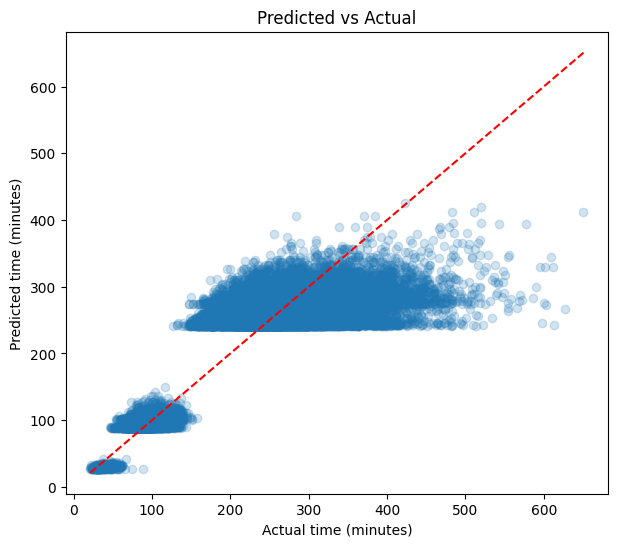

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# convert back from log(secs) -> secs -> mins
actual_minutes = np.exp(y_test) / 60
pred_minutes = np.exp(pred_log) / 60

plt.figure(figsize=(7, 6))
plt.scatter(actual_minutes, pred_minutes, alpha=0.2)
plt.plot(
    [actual_minutes.min(), actual_minutes.max()],
    [actual_minutes.min(), actual_minutes.max()],
    "r--"
)
plt.xlabel("Actual time (minutes)")
plt.ylabel("Predicted time (minutes)")
plt.title("Predicted vs Actual")
plt.show()